In [20]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# This makes graphs look better
sns.set_style("whitegrid")

In [21]:
# Read the CSV file

df = pd.read_csv("sales_data.csv")

# Show first 5 rows
df.head()

,Date,Product,Region,Sales_Amount,Quantity
0,2025-01-02,Laptop,North,55000,2
1,2025-01-05,Phone,South,24000,3
2,2025-01-08,Tablet,East,18000,2
3,2025-01-10,Headphones,West,4000,5
4,2025-01-15,Laptop,South,60000,2


In [22]:
# Check dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Date          40 non-null     str  
 1   Product       40 non-null     str  
 2   Region        40 non-null     str  
 3   Sales_Amount  40 non-null     int64
 4   Quantity      40 non-null     int64
dtypes: int64(2), str(3)
memory usage: 1.7 KB


In [23]:
# Check if any values are missing

print(df.isnull().sum())

Date            0
Product         0
Region          0
Sales_Amount    0
Quantity        0
dtype: int64


In [24]:
# Show statistical summary

df.describe()

,Sales_Amount,Quantity
count,40.000000,40.000000
mean,31630.000000,3.900000
std,22244.817316,1.691608
min,3500.000000,2.000000
25%,19125.000000,3.000000
50%,26500.000000,3.500000
75%,55750.000000,5.000000
max,72000.000000,8.000000


In [25]:
# Check duplicate records

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [26]:
# Convert Date column into datetime format

df["Date"] = pd.to_datetime(df["Date"])

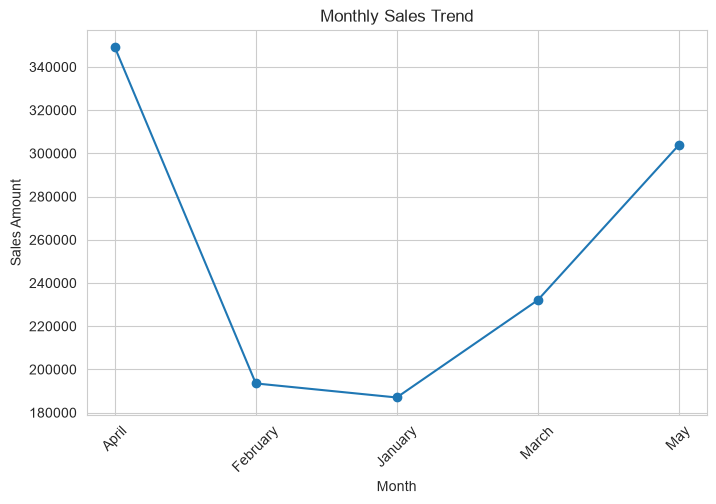

In [27]:
#task 3
# Create a Month column

df["Month"] = df["Date"].dt.month_name()

# Calculate monthly sales

monthly_sales = df.groupby("Month")["Sales_Amount"].sum()

# Plot line graph

plt.figure(figsize=(8,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")

plt.xticks(rotation=45)

plt.show()

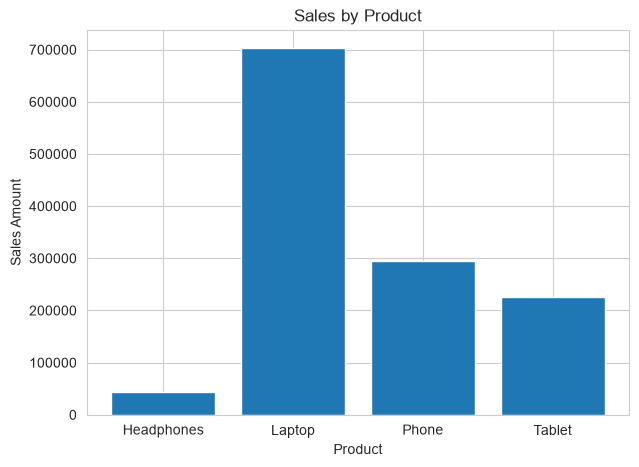

In [28]:
#task 4
# Total sales by product

product_sales = df.groupby("Product")["Sales_Amount"].sum()

plt.figure(figsize=(7,5))

plt.bar(product_sales.index,
        product_sales.values)

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales Amount")

plt.show()

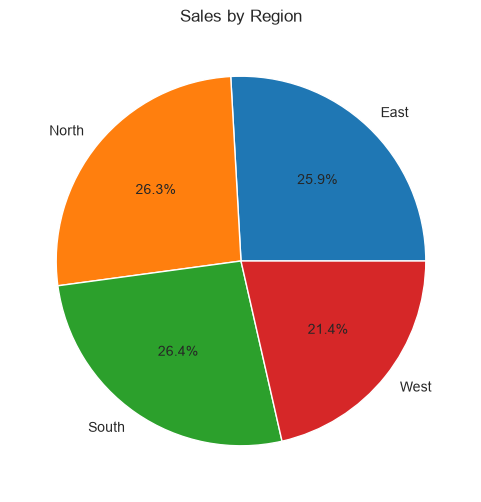

In [29]:
#task 4
# Total sales by region

region_sales = df.groupby("Region")["Sales_Amount"].sum()

plt.figure(figsize=(6,6))

plt.pie(region_sales,
        labels=region_sales.index,
        autopct="%1.1f%%")

plt.title("Sales by Region")

plt.show()

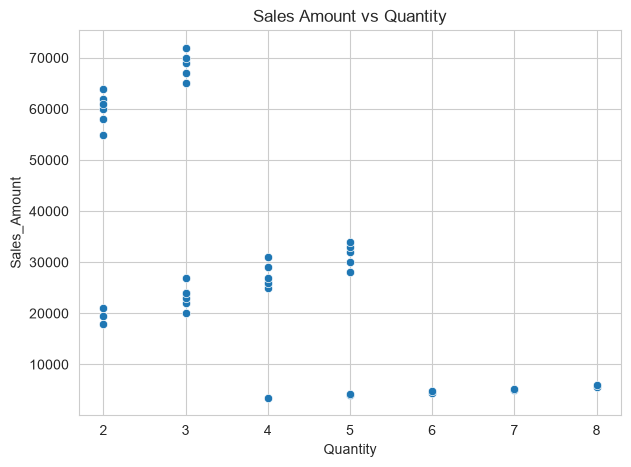

In [30]:
#task 5
# Compare Quantity and Sales Amount

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Sales_Amount"
)

plt.title("Sales Amount vs Quantity")

plt.show()

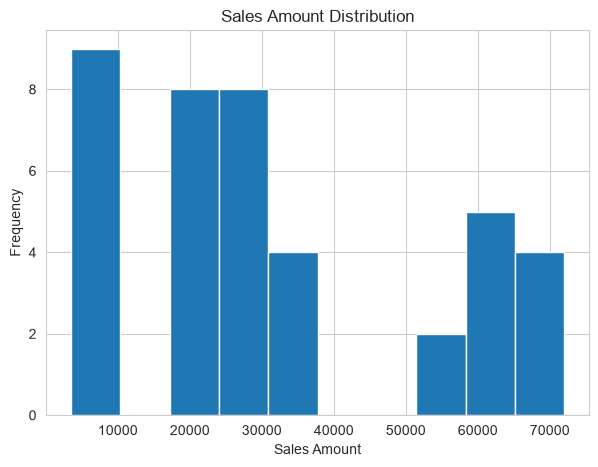

In [31]:
#Histogram
# Distribution of Sales Amount

plt.figure(figsize=(7,5))

plt.hist(df["Sales_Amount"],
         bins=10)

plt.title("Sales Amount Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")

plt.show()

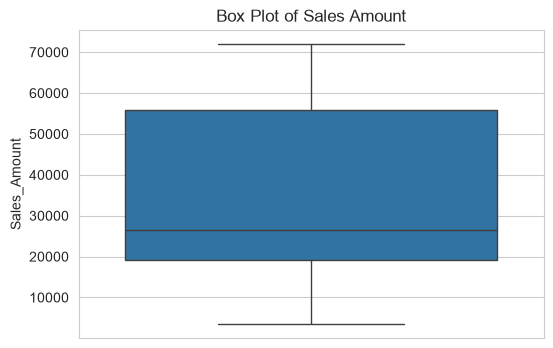

In [32]:
#Box Plot
# Check spread and outliers

plt.figure(figsize=(6,4))

sns.boxplot(
    y=df["Sales_Amount"]
)

plt.title("Box Plot of Sales Amount")

plt.show()

In [33]:
#Insight
# Print important findings

print("Project Insights")
print("-----------------------")

print("Highest Product Sales:")
print(product_sales.idxmax())

print()

print("Highest Sales Region:")
print(region_sales.idxmax())

print()

print("Average Sales Amount:")
print(df["Sales_Amount"].mean())

print()

print("Maximum Sales:")
print(df["Sales_Amount"].max())

Project Insights
-----------------------
Highest Product Sales:
Laptop

Highest Sales Region:
South

Average Sales Amount:
31630.0

Maximum Sales:
72000
